In [ ]:
from pathlib import Path
import pandas as pd

def find_project_root():
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / '.git').exists() or (parent / 'data').exists():
            return parent
    return current

PROJECT_ROOT = find_project_root()
DATA_EXTERNAL = PROJECT_ROOT / 'data' / 'external'

print(f"Check: Proyecto raíz: {PROJECT_ROOT}")
print(f"Check: Datos external: {DATA_EXTERNAL}")

import pandas as pd
df = pd.read_csv(DATA_EXTERNAL / 'Titanic_train_and_test2.csv')
df.head()

Check: Proyecto raíz: c:\Users\alefe\OneDrive\Documentos\GitHub\data-analytics-project
Check: Datos external: c:\Users\alefe\OneDrive\Documentos\GitHub\data-analytics-project\data\external


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
#Sirve para identificar las columnas y sus DataTypes
df.dtypes

Passengerid           int64
Pclass                int64
Sex                     str
Age                 float64
Fare                float64
Embarked            float64
sibsp                 int64
Parch                 int64
2urvived              int64
Fare_media_clase    float64
dtype: object

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [3]:
df.columns.tolist()

['Passengerid',
 'Age',
 'Fare',
 'Sex',
 'sibsp',
 'zero',
 'zero.1',
 'zero.2',
 'zero.3',
 'zero.4',
 'zero.5',
 'zero.6',
 'Parch',
 'zero.7',
 'zero.8',
 'zero.9',
 'zero.10',
 'zero.11',
 'zero.12',
 'zero.13',
 'zero.14',
 'Pclass',
 'zero.15',
 'zero.16',
 'Embarked',
 'zero.17',
 'zero.18',
 '2urvived']

In [4]:
df = df[["Passengerid", "Pclass", "Sex", "Age", "Fare", "Embarked", "sibsp", "Parch", "2urvived"]]
df.head()

,Passengerid,Pclass,Sex,Age,Fare,Embarked,sibsp,Parch,2urvived
0,1,3,0,22.0,7.2500,2.0,1,0,0
1,2,1,1,38.0,71.2833,0.0,1,0,1
2,3,3,1,26.0,7.9250,2.0,0,0,1
3,4,1,1,35.0,53.1000,2.0,1,0,1
4,5,3,0,35.0,8.0500,2.0,0,0,0


In [5]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    87.508992
2    21.179196
3    13.304513
Name: Fare, dtype: float64

In [6]:
df.groupby("Pclass")["Fare"].agg(["mean","min","max"])


,mean,min,max
Pclass,,,
1,87.508992,0.0,512.3292
2,21.179196,0.0,73.5000
3,13.304513,0.0,69.5500


In [7]:
df["Sex"] = df["Sex"].map({0: "male", 1: "female"})



In [8]:
df.groupby(["Pclass", "Sex"])["2urvived"].mean() * 100

Pclass  Sex   
1       female    63.194444
        male      25.139665
2       female    66.037736
        male       9.941520
3       female    33.333333
        male       9.533469
Name: 2urvived, dtype: float64

In [9]:
resultado = df.groupby(["Pclass", "Sex"])["2urvived"].mean() * 100
resultado.map("{:.1f}%".format)

Pclass  Sex   
1       female    63.2%
        male      25.1%
2       female    66.0%
        male       9.9%
3       female    33.3%
        male       9.5%
Name: 2urvived, dtype: str

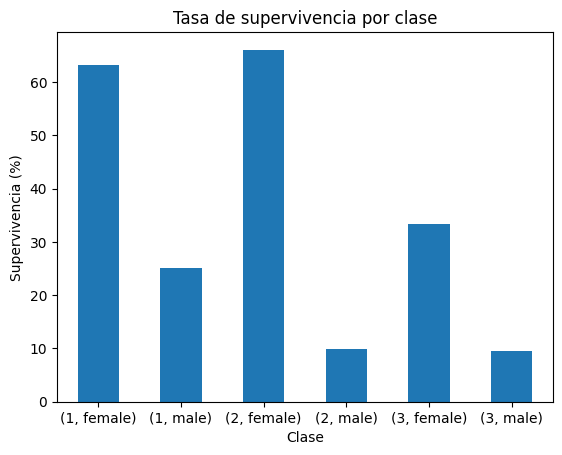

In [10]:
import matplotlib.pyplot as plt

resultado = df.groupby(["Pclass","Sex"])["2urvived"].mean()*100

resultado.plot(kind="bar")
plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Supervivencia (%)")
plt.xticks(rotation=0)
plt.show()

In [11]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    87.508992
2    21.179196
3    13.304513
Name: Fare, dtype: float64

In [12]:
df.groupby("Pclass").agg({
    "Fare": "mean",
    "Age": "max",
    "2urvived": "sum"
})

,Fare,Age,2urvived
Pclass,,,
1,87.508992,80.0,136
2,21.179196,70.0,87
3,13.304513,74.0,119


In [13]:
df["Fare_media_clase"] = df.groupby("Pclass")["Fare"].transform("mean")
df[["Pclass", "Fare", "Fare_media_clase"]].head(10)

,Pclass,Fare,Fare_media_clase
0,3,7.2500,13.304513
1,1,71.2833,87.508992
2,3,7.9250,13.304513
3,1,53.1000,87.508992
4,3,8.0500,13.304513
5,3,8.4583,13.304513
6,1,51.8625,87.508992
7,3,21.0750,13.304513
8,3,11.1333,13.304513
9,2,30.0708,21.179196


In [14]:
df.groupby("Pclass")["Fare_media_clase"].unique()


Pclass
1     [87.50899164086688]
2    [21.179196389891697]
3    [13.304512552891397]
Name: Fare_media_clase, dtype: object

In [15]:
df_filtrado = df.groupby("Pclass").filter(lambda x: len(x) > 400)
df_filtrado["Pclass"].value_counts()


Pclass
3    709
Name: count, dtype: int64

In [16]:
df.groupby("Pclass").size()



Pclass
1    323
2    277
3    709
dtype: int64

In [17]:
df.groupby("Pclass").count()

,Passengerid,Sex,Age,Fare,Embarked,sibsp,Parch,2urvived,Fare_media_clase
Pclass,,,,,,,,,
1,323,323,323,323,321,323,323,323,323
2,277,277,277,277,277,277,277,277,277
3,709,709,709,709,709,709,709,709,709


In [18]:
resultado = df.groupby(["Pclass", "Sex"])["2urvived"].mean()
resultado

Pclass  Sex   
1       female    0.631944
        male      0.251397
2       female    0.660377
        male      0.099415
3       female    0.333333
        male      0.095335
Name: 2urvived, dtype: float64

In [19]:
resultado.unstack()

Sex,female,male
Pclass,,
1,0.631944,0.251397
2,0.660377,0.099415
3,0.333333,0.095335
